# R10 topology quartet - H87 AFRC, H88 effective resistance, H91 super-hub autopsy, H97 chain variance

**Author**: Knowledge Graph Foundry autonomous build (kj) <br>
**Date**: 2026-07-06 <br>
**Pipeline stage**: R10 research-grounded round, curvature/topology family <br>
**Graph**: rebuilt CPAP graph (neo4j2) <br>

Four detectors over one graph load, all aimed at the SAME_AS surface the forensics exposed
(127 edges, model_code = 73 and visibly false members). Labels: the 6 category-labeled false
merges (clean negatives among merges) vs same-name pairs (presumed-true) - small n, honestly
reported; H101's benchmark supersedes.

- **H87** - augmented Forman-Ricci curvature: false closure edges are bridges (no shared triangles) -> more negative AFRC; bar AUC >= 0.7
- **H88** - effective resistance: a spurious SAME_AS is the SOLE path between its endpoints (R_uv -> 1); a true one is redundant (R_uv << 1); bar >= 70% recall at zero true loss
- **H91** - the degree-236 hub: legitimate entity (curvature-normal, expected component behavior) or over-merge sink; either verdict recorded
- **H97** - SAME_AS cluster embedding variance: high intra-cluster spread flags false members; bar >= 70% recall at precision > 0.5

## Outputs
- `reports/topology-r10-<stamp>.json` - all four verdicts with distributions

In [1]:
# Imports
# stdlib
import datetime, json, os, re
from collections import defaultdict

# third party
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from rich import print as rprint
from sklearn.metrics import roc_auc_score

os.environ["NEO4J_URI"] = "bolt://user-konrad.jelen-kgf-neo4j2:7687"
os.environ["NEO4J_USER"] = "neo4j"
os.environ["NEO4J_PASSWORD"] = "kgfoundry"
from neo4j import GraphDatabase

BAR_AUC_H87 = 0.7
BAR_RECALL_H88 = 0.7
BAR_RECALL_H97 = 0.7
TOP_HUBS = 5

In [2]:
driver = GraphDatabase.driver(os.environ["NEO4J_URI"],
    auth=(os.environ["NEO4J_USER"], os.environ["NEO4J_PASSWORD"]), notifications_min_severity="OFF")
with driver.session() as s:
    ents = s.run("MATCH (e:Entity) RETURN e.id AS id, e.name AS name, e.embedding AS emb").data()
    edges = s.run("MATCH (a:Entity)-[r]-(b:Entity) WHERE r.valid_to IS NULL AND type(r) <> 'SIMILAR_TO' "
                  "AND a.id < b.id RETURN DISTINCT a.id AS a, b.id AS b").data()
    same_as = s.run("MATCH (a:Entity)-[r:SAME_AS]->(b:Entity) "
                    "RETURN a.id AS a, b.id AS b, r.method AS m").data()
driver.close()

name_of = {r["id"]: r["name"] for r in ents}
emb_of = {r["id"]: np.array(r["emb"], dtype=np.float32) for r in ents if r["emb"]}
adj = defaultdict(set)
for e in edges:
    adj[e["a"]].add(e["b"]); adj[e["b"]].add(e["a"])
deg = {n: len(v) for n, v in adj.items()}

# labels from the identity forensics
import glob
inv = json.load(open(sorted(glob.glob("../reports/identity-forensics-r11-final-*.json"))[-1]))
false_pairs = {frozenset((m["a"], m["b"])) for m in inv["labeled_false_merges"]}
squash = lambda n: re.sub(r"[^a-z0-9]", "", (n or "").casefold())
sa_edges = []
for r in same_as:
    if r["a"] in adj and r["b"] in adj:
        lbl = "false" if frozenset((name_of[r["a"]], name_of[r["b"]])) in false_pairs else (
              "true" if squash(name_of[r["a"]]) == squash(name_of[r["b"]]) else "unknown")
        sa_edges.append({"a": r["a"], "b": r["b"], "m": r["m"], "label": lbl})
from collections import Counter
rprint(f"entities: [yellow]{len(ents)}[/yellow]  edges: [yellow]{len(edges)}[/yellow]  "
       f"SAME_AS labeled: {dict(Counter(e['label'] for e in sa_edges))}")

entities: 2798  edges: 3738  SAME_AS labeled: {'unknown': 101, 'false': 6, 'true': 20}

## H87 - AFRC on the SAME_AS edges

AFRC(u,v) = 4 - deg(u) - deg(v) + 3 x triangles(u,v). Bridges (no shared neighbors) go strongly
negative on high-degree endpoints; true co-references embedded in shared neighborhoods gain the
triangle bonus.

In [3]:
def afrc(u, v):
    tri = len(adj[u] & adj[v])
    return 4 - deg.get(u, 0) - deg.get(v, 0) + 3 * tri

for e in sa_edges:
    e["afrc"] = afrc(e["a"], e["b"])
    e["triangles"] = len(adj[e["a"]] & adj[e["b"]])

lab = [e for e in sa_edges if e["label"] != "unknown"]
ys = [1 if e["label"] == "false" else 0 for e in lab]
ss = [-e["afrc"] for e in lab]  # more negative curvature -> higher false-score
auc87 = float(roc_auc_score(ys, ss)) if len(set(ys)) > 1 else None
h87 = "CONFIRMED" if auc87 and auc87 >= BAR_AUC_H87 else "REFUTED"
rprint(f"[bold cyan]H87 AFRC[/bold cyan]  labeled n={len(lab)} (false {sum(ys)})  "
       f"AUC [yellow]{auc87:.3f}[/yellow] (bar {BAR_AUC_H87}) -> [{'green' if h87=='CONFIRMED' else 'red'}]{h87}[/]")
for e in sorted(lab, key=lambda x: x["afrc"])[:8]:
    rprint(f"  afrc {e['afrc']:4d} tri {e['triangles']} [{'red' if e['label']=='false' else 'green'}]{e['label']:5s}[/] {name_of[e['a']]} <-> {name_of[e['b']]}")

H87 AFRC  labeled n=26 (false 6)  AUC 0.617 (bar 0.7) -> REFUTED

afrc  -56 tri 0 false DreamStation CPAP <-> Air Filter

afrc  -51 tri 1 false DreamStation CPAP <-> Filter

afrc  -17 tri 1 true  ISO 80601-2-70:2015 <-> ISO 80601-2-70:2015

afrc   -8 tri 1 true  Full face mask <-> Full-Face Mask

afrc   -6 tri 0 true  Flow Meter <-> Flowmeter

afrc   -6 tri 0 true  Ultra-Fine Filter Disposable 1 Pack <-> Ultra-fine Filter Disposable 1-pack

afrc   -5 tri 0 true  Performance Tubing (22mm) <-> Performance Tubing 22mm

afrc   -4 tri 0 true  Pre-heat <-> Preheat

## H88 - effective resistance: is the SAME_AS edge the sole path?

Laplacian pseudoinverse on the giant component; R_uv = L+_uu + L+_vv - 2 L+_uv. R_uv near 1 =
the edge itself is the only path (spurious bridge); R_uv well below 1 = redundant neighborhood
(true co-reference).

H88 effective resistance  AUC 0.458  R>=0.95: recall of false 0.17 (bar 0.7), true flagged 1 -> REFUTED

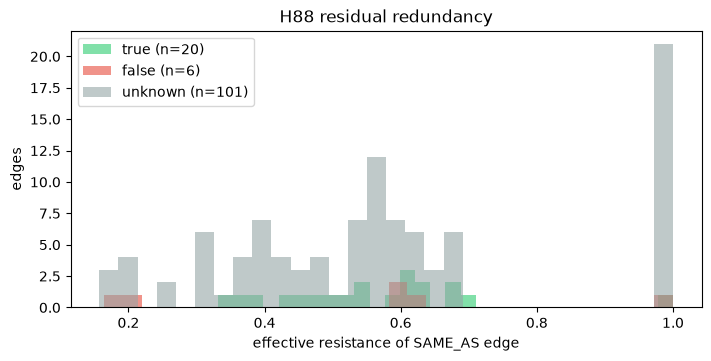

In [4]:
nodes = sorted(adj)
idx = {n: i for i, n in enumerate(nodes)}
N = len(nodes)
L = np.zeros((N, N), dtype=np.float64)
for e in edges:
    i, j = idx[e["a"]], idx[e["b"]]
    L[i, i] += 1; L[j, j] += 1; L[i, j] -= 1; L[j, i] -= 1
Lp = np.linalg.pinv(L, hermitian=True)

def eff_res(u, v):
    i, j = idx[u], idx[v]
    return float(Lp[i, i] + Lp[j, j] - 2 * Lp[i, j])

for e in sa_edges:
    e["R"] = eff_res(e["a"], e["b"])

ssR = [e["R"] for e in lab]
auc88 = float(roc_auc_score(ys, ssR)) if len(set(ys)) > 1 else None
thr = 0.95
flagged = [e for e in sa_edges if e["R"] >= thr]
rec88 = sum(1 for e in flagged if e["label"] == "false") / max(sum(ys), 1)
true_loss88 = sum(1 for e in flagged if e["label"] == "true")
h88 = "CONFIRMED" if rec88 >= BAR_RECALL_H88 and true_loss88 == 0 else "REFUTED"
rprint(f"[bold cyan]H88 effective resistance[/bold cyan]  AUC [yellow]{auc88:.3f}[/yellow]  "
       f"R>={thr}: recall of false [yellow]{rec88:.2f}[/yellow] (bar {BAR_RECALL_H88}), true flagged [red]{true_loss88}[/red] "
       f"-> [{'green' if h88=='CONFIRMED' else 'red'}]{h88}[/]")
fig, ax = plt.subplots(figsize=(7, 3.5), constrained_layout=True)
for label, color in [("true", "#2ECC71"), ("false", "#E74C3C"), ("unknown", "#95A5A6")]:
    vals = [e["R"] for e in sa_edges if e["label"] == label]
    if vals:
        ax.hist(vals, bins=30, alpha=0.6, label=f"{label} (n={len(vals)})", color=color)
ax.set(xlabel="effective resistance of SAME_AS edge", ylabel="edges", title="H88 residual redundancy")
ax.legend(); plt.show()

## H91 - super-hub autopsy

Top-5 hubs: incident-edge AFRC vs the graph norm, and removal component analysis (how many of
the hub's neighbors remain connected to the giant component without it).

In [5]:
all_afrc = [afrc(e["a"], e["b"]) for e in edges]
norm_mean, norm_std = float(np.mean(all_afrc)), float(np.std(all_afrc))

def component_of(start, adjx, banned):
    seen, q = {start}, [start]
    while q:
        u = q.pop()
        for v in adjx[u]:
            if v != banned and v not in seen:
                seen.add(v); q.append(v)
    return seen

hubs = sorted(deg, key=lambda n: -deg[n])[:TOP_HUBS]
autopsy = []
for h in hubs:
    inc = [afrc(h, v) for v in adj[h]]
    z = (np.mean(inc) - norm_mean) / max(norm_std, 1e-9)
    neigh = list(adj[h])
    anchor = neigh[0]
    reachable = component_of(anchor, adj, banned=h)
    stranded = sum(1 for v in neigh[1:] if v not in reachable)
    autopsy.append({"name": name_of[h], "degree": deg[h], "afrc_z": float(z),
                    "stranded_neighbors": stranded, "stranded_frac": stranded / max(len(neigh) - 1, 1)})

# legitimate hub: curvature near norm (|z| < 2) - star centers strand neighbors by NATURE,
# so strandedness alone cannot convict; the conviction pattern is anomalous curvature + strand
suspicious = [a for a in autopsy if abs(a["afrc_z"]) >= 2]
h91 = "CONFIRMED (hubs legitimate)" if not suspicious else "REFUTED (over-merge sink found)"
rprint(f"[bold cyan]H91 super-hub autopsy[/bold cyan]  graph AFRC mean {norm_mean:.1f} sd {norm_std:.1f}")
for a in autopsy:
    rprint(f"  deg [yellow]{a['degree']:4d}[/yellow] z [yellow]{a['afrc_z']:+.2f}[/yellow] "
           f"stranded {a['stranded_frac']:.0%}  {a['name'][:60]}")
rprint(f"  -> [{'green' if not suspicious else 'red'}]{h91}[/]")

H91 super-hub autopsy  graph AFRC mean -39.4 sd 55.9

deg  214 z -3.09 stranded 100%  iBreeze CPAP System

deg  150 z -2.01 stranded 35%  Philips Respironics

deg  122 z -1.45 stranded 62%  AirSense 11

deg   76 z -0.67 stranded 20%  DreamStation CPAP Pro

deg   74 z -0.59 stranded 36%  RESmart CPAP

-> REFUTED (over-merge sink found)

## H97 - chain variance: the cheapest false-closure filter

SAME_AS connected components (clusters, size >= 3); intra-cluster mean pairwise cosine and
max member distance to centroid. Clusters containing a labeled-false edge = bad.

In [6]:
sa_adj = defaultdict(set)
for e in sa_edges:
    sa_adj[e["a"]].add(e["b"]); sa_adj[e["b"]].add(e["a"])
seen, clusters = set(), []
for n in sa_adj:
    if n in seen:
        continue
    comp = component_of(n, sa_adj, banned=None)
    seen |= comp
    if len(comp) >= 3:
        clusters.append(sorted(comp))

bad_edge_nodes = {x for e in sa_edges if e["label"] == "false" for x in (e["a"], e["b"])}
rows97 = []
for comp in clusters:
    vs = [emb_of[c] / np.linalg.norm(emb_of[c]) for c in comp if c in emb_of]
    if len(vs) < 3:
        continue
    V = np.stack(vs)
    centroid = V.mean(0); centroid /= np.linalg.norm(centroid)
    dists = 1 - V @ centroid
    sims = V @ V.T
    tri = sims[np.triu_indices(len(vs), 1)]
    rows97.append({"members": [name_of[c][:40] for c in comp], "n": len(vs),
                   "mean_pair_cos": float(tri.mean()), "max_centroid_dist": float(dists.max()),
                   "bad": any(c in bad_edge_nodes for c in comp)})

ys97 = [1 if r["bad"] else 0 for r in rows97]
ss97 = [r["max_centroid_dist"] for r in rows97]
auc97 = float(roc_auc_score(ys97, ss97)) if len(set(ys97)) > 1 else None
k = sum(ys97)
flagged97 = sorted(rows97, key=lambda r: -r["max_centroid_dist"])[:max(k * 2, 3)]
rec97 = sum(1 for r in flagged97 if r["bad"]) / max(k, 1)
prec97 = sum(1 for r in flagged97 if r["bad"]) / max(len(flagged97), 1)
h97 = "CONFIRMED" if rec97 >= BAR_RECALL_H97 and prec97 > 0.5 else "REFUTED"
rprint(f"[bold cyan]H97 chain variance[/bold cyan]  clusters(>=3): [yellow]{len(rows97)}[/yellow] "
       f"(bad {k})  AUC [yellow]{auc97 if auc97 else 'n/a'}[/yellow]  "
       f"top-{len(flagged97)} recall [yellow]{rec97:.2f}[/yellow] precision [yellow]{prec97:.2f}[/yellow] "
       f"-> [{'green' if h97=='CONFIRMED' else 'red'}]{h97}[/]")
for r in sorted(rows97, key=lambda r: -r["max_centroid_dist"])[:6]:
    rprint(f"  [{'red' if r['bad'] else 'dim'}]{'bad ' if r['bad'] else 'ok  '}[/] d_max {r['max_centroid_dist']:.3f} {r['members'][:4]}")

stamp = datetime.datetime.now(datetime.timezone.utc).strftime("%Y%m%d-%H%M%S")
out = Path("../reports") / f"topology-r10-{stamp}.json"
out.write_text(json.dumps({
    "h87": {"auc": auc87, "verdict": h87, "n_labeled": len(lab)},
    "h88": {"auc": auc88, "recall": rec88, "true_flagged": true_loss88, "verdict": h88},
    "h91": {"autopsy": autopsy, "verdict": h91},
    "h97": {"auc": auc97, "recall": rec97, "precision": prec97, "n_clusters": len(rows97), "verdict": h97,
             "clusters": rows97},
    "sa_edges": [{"a": name_of[e["a"]], "b": name_of[e["b"]], "m": e["m"], "label": e["label"],
                    "afrc": e["afrc"], "R": e["R"]} for e in sa_edges],
}, indent=2, default=str))
rprint("saved", str(out))

H97 chain variance  clusters(>=3): 18 (bad 3)  AUC 0.7555555555555555  top-6 recall 0.33 precision 0.17 -> REFUTED

bad  d_max 0.759 ['Auto', 'CPAP mask', 'DreamStation CPAP', 'MANU']

ok   d_max 0.490 ['DreamStation SpO2 module', 'SpO2 sensor (finger clip)', 'SpO2 extension cable', 'SpO2']

ok   d_max 0.458 ['Trilogy O2 quick-disconnect insert', 'High Precision O2 Concentration Detectio', 'Oxymixer Air
and O2 Blender', 'Air and O2 Hoses']

ok   d_max 0.412 ['Sleepware G3 Getting Started Guide, Engl', 'Sleepware G3', 'Sleepware G3, Multi-language', 'G3
A20']

ok   d_max 0.372 ['CoughAssist T70 Roll Stand', 'CoughAssist T70 Foot Pedal', 'CoughAssist T70 Battery Cover', 
'CoughAssist T70 Carrying Case']

ok   d_max 0.338 ['AirFit P10 bedside starter kit', 'AirFit P10 for AirMini', 'Transcend P10 battery', 'AirFit 
P10']

saved ../reports/topology-r10-20260706-211957.json